In [14]:
import pandas as pd

In [15]:
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
#train.head()
train["Age"] = train["Age"].fillna(train["Age"].median())
counts = train.isnull().sum()
counts

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

        Survived  Died
Sex                   
female       233    81
male         109   468


<Axes: xlabel='Sex'>

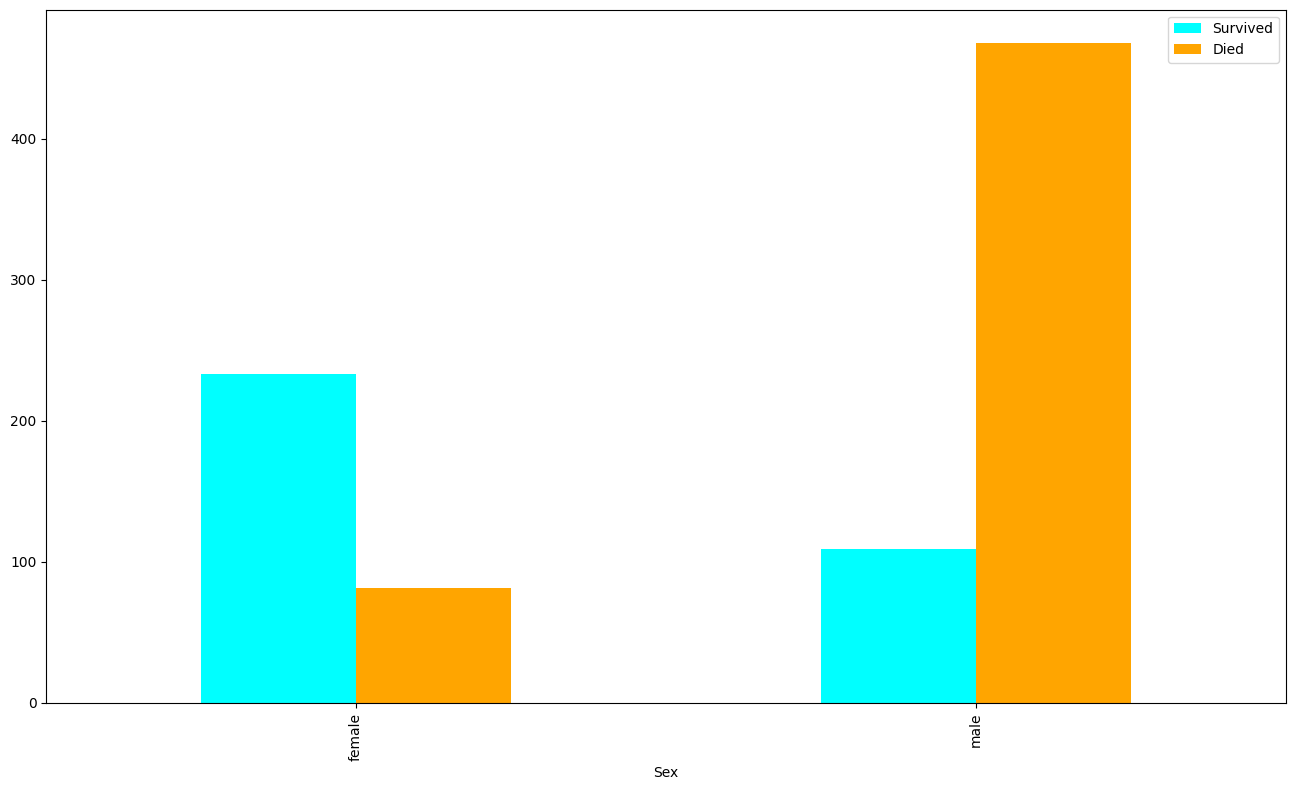

In [16]:
# 1 = died, 0 = survived
data = train.copy()
data["Died"] = 1 - data["Survived"]

# Count survived and died for each sex
sex_data = data.groupby("Sex")[
            ["Survived", "Died"]].sum()
print(sex_data.head())
sex_data.plot(
    kind = 'bar',
    stacked = False, 
    figsize = (16, 9),
    color = ["cyan", "orange"]
)

             PassengerId  Survived    Pclass       Age     SibSp     Parch  \
PassengerId     1.000000 -0.005007 -0.035144  0.034212 -0.057527 -0.001652   
Survived       -0.005007  1.000000 -0.338481 -0.064910 -0.035322  0.081629   
Pclass         -0.035144 -0.338481  1.000000 -0.339898  0.083081  0.018443   
Age             0.034212 -0.064910 -0.339898  1.000000 -0.233296 -0.172482   
SibSp          -0.057527 -0.035322  0.083081 -0.233296  1.000000  0.414838   
Parch          -0.001652  0.081629  0.018443 -0.172482  0.414838  1.000000   
Fare            0.012658  0.257307 -0.549500  0.096688  0.159651  0.216225   
Died            0.005007 -1.000000  0.338481  0.064910  0.035322 -0.081629   

                 Fare      Died  
PassengerId  0.012658  0.005007  
Survived     0.257307 -1.000000  
Pclass      -0.549500  0.338481  
Age          0.096688  0.064910  
SibSp        0.159651  0.035322  
Parch        0.216225 -0.081629  
Fare         1.000000 -0.257307  
Died        -0.257307  1.

<Axes: >

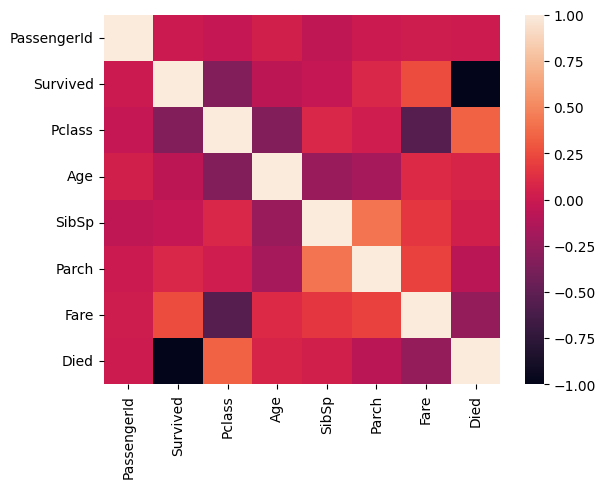

In [17]:
import seaborn as sns
num = data.select_dtypes(include = "number")
print(num.corr())

sns.heatmap(num.corr())

<Axes: >

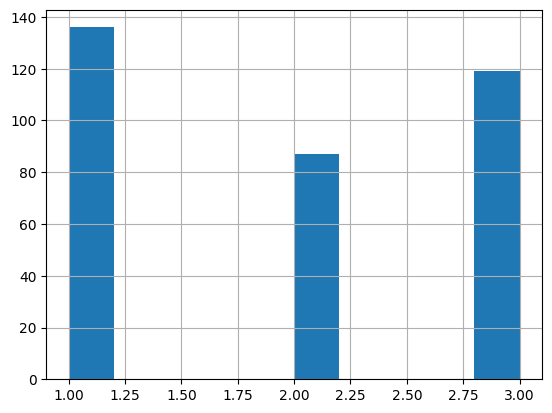

In [18]:
data[data["Survived"]==1]["Pclass"].hist()

In [19]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Died
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1


                Survived  Multiple_cabin
Survived        1.000000        0.277053
Multiple_cabin  0.277053        1.000000


<Axes: >

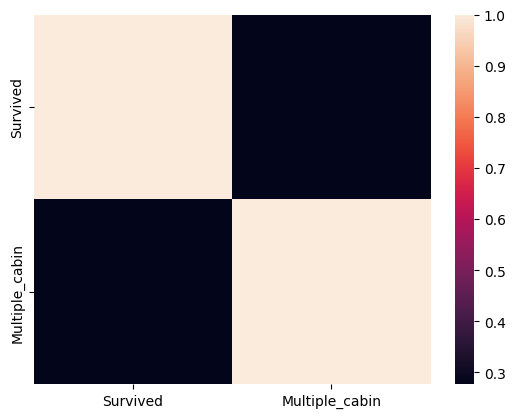

In [20]:
def count_cabin(cabin):
    if(pd.isna(cabin)): return 0
    temp = cabin.split()
    return len(temp)
data["Multiple_cabin"] = data["Cabin"].apply(count_cabin)
data["Multiple_cabin"].value_counts()
temp = data[["Survived", "Multiple_cabin"]]
heat_map = temp.corr()
print(heat_map)
sns.heatmap(heat_map)

<Axes: >

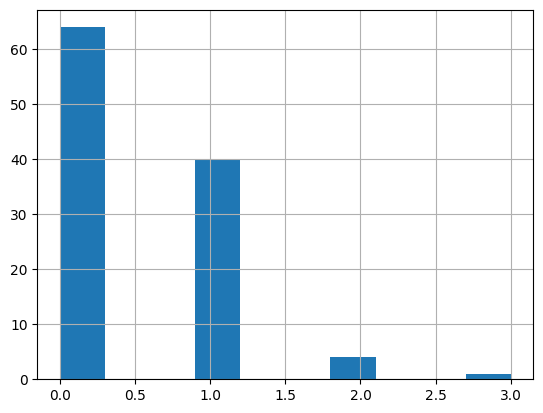

In [21]:
data[(data["Survived"]==1) & (data["Sex"]=="male")]["Multiple_cabin"].hist()

In [22]:
data["Ticket"]

0             A/5 21171
1              PC 17599
2      STON/O2. 3101282
3                113803
4                373450
             ...       
886              211536
887              112053
888          W./C. 6607
889              111369
890              370376
Name: Ticket, Length: 891, dtype: object

In [23]:
pd.pivot_table(data, 
              index = "Survived", 
              columns = "Multiple_cabin", 
              values = "PassengerId", 
              aggfunc = 'count')

Multiple_cabin,0,1,2,3,4
Survived,,,,,
0,481.0,58.0,7.0,3.0,NaN
1,206.0,122.0,9.0,3.0,2.0


In [24]:
data["Cabin_adv"] = train["Cabin"].apply(lambda x: str(x)[0])
data["Cabin_adv"] 

0      n
1      C
2      n
3      C
4      n
      ..
886    n
887    B
888    n
889    C
890    n
Name: Cabin_adv, Length: 891, dtype: object

In [26]:
pd.pivot_table(data, 
              index = "Survived", 
              columns = "Cabin_adv", 
              values = "PassengerId", 
              aggfunc = 'count')

Cabin_adv,A,B,C,D,E,F,G,T,n
Survived,,,,,,,,,
0,8.0,12.0,24.0,8.0,8.0,5.0,2.0,1.0,481.0
1,7.0,35.0,35.0,25.0,24.0,8.0,2.0,NaN,206.0


In [46]:
data['Ticket_letters']=data["Ticket"].apply(lambda x: "".join(str(x).replace('.','').replace('/','').lower().split(' ')[:-1])
                                           if len(str(x).split()) > 1 else 0)
data['Ticket_numerical'] = data['Ticket'].apply(lambda x: 1 if x.isnumeric() else 0)
data["Ticket_letters"]

0          a5
1          pc
2      stono2
3           0
4           0
        ...  
886         0
887         0
888        wc
889         0
890         0
Name: Ticket_letters, Length: 891, dtype: object

In [52]:
data['Ticket_numerical'].value_counts()

Ticket_numerical
1    661
0    230
Name: count, dtype: int64

In [53]:
data['Name'].head()

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
Name: Name, dtype: object

In [61]:
# feature engineering on name (retriving title)
def title(name):
    name = name.split('.')[0].split(' ')[1].strip()
    return name
data["Title"] = data["Name"].apply(lambda x:x.split('.')[0].split(' ')[1].strip())
data["Title"] = data["Name"].apply(title)
data["Title"]

0        Mr
1       Mrs
2      Miss
3       Mrs
4        Mr
       ... 
886     Rev
887    Miss
888    Miss
889      Mr
890      Mr
Name: Title, Length: 891, dtype: object

In [70]:
data.isnull().sum()

PassengerId           0
Survived              0
Pclass                0
Name                  0
Sex                   0
Age                   0
SibSp                 0
Parch                 0
Ticket                0
Fare                  0
Cabin               687
Embarked              2
Died                  0
Multiple_cabin        0
Cabin_adv             0
Ticket_letters        0
Ticket_numerical      0
Title                 0
dtype: int64

In [77]:
data[data["Cabin"].str.split('.').str.len() > 1]["Cabin"]

Series([], Name: Cabin, dtype: object)

In [103]:
def feature_engineering(df):
    df["Title"] = df["Name"].str.split(',').str[1].str.split('.').str[0].str.strip()    
    df["Cabin_multi"] = df["Cabin"].apply(lambda x: len(x.split()) 
                                       if (pd.isna(x)==False) else 0)
    df['Cabin_adv'] = df['Cabin'].apply(lambda x: str(x)[0])
    df["Ticket_numeric"] = df["Ticket"].str.isnumeric().astype(int)
    df["Ticket-letter"] = (df['Ticket'].str.split(' ')
                                          .str[:-1]
                                          .str.join("")
                                          .str.replace('/','')
                                          .str.replace(' ','')
                                          .str.lower()
                                          .replace('',0)
                          )
    return df
train = feature_engineering(train)
test = feature_engineering(test)
#train.drop(columns = ["Survived"])
train.drop("Survived", axis=1)
X_test = test.copy()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Cabin_multi,Cabin_adv,Ticket_numeric,Ticket-letter
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,0,n,0,a5
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,1,C,0,pc
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,0,n,0,stono2.
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,1,C,1,0
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,0,n,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev,0,n,1,0
887,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss,1,B,1,0
888,889,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,NaN,S,Miss,0,n,0,w.c.
889,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr,1,C,1,0
